In [1]:
import torch.nn as nn
import torch


class BasicBlock1D(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.conv1 = nn.Conv1d(in_ch, out_ch, kernel_size=3, stride=stride, padding=1)
        self.bn1 = nn.BatchNorm1d(out_ch)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv1d(out_ch, out_ch, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm1d(out_ch)

        self.downsample = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.downsample = nn.Sequential(
                nn.Conv1d(in_ch, out_ch, kernel_size=1, stride=stride),
                nn.BatchNorm1d(out_ch)
            )

    def forward(self, x):
        identity = self.downsample(x)
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += identity
        return self.relu(out)

class CEEDNet1DResNet18(nn.Module):
    def __init__(self, in_channels=10, num_classes=3):
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels, 64, kernel_size=7, stride=2, padding=3)
        self.bn1 = nn.BatchNorm1d(64)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool1d(kernel_size=3, stride=2, padding=1)

        self.layer1 = self._make_layer(64, 64, blocks=2)
        self.layer2 = self._make_layer(64, 128, blocks=2, stride=2)
        self.layer3 = self._make_layer(128, 256, blocks=2, stride=2)
        self.layer4 = self._make_layer(256, 512, blocks=2, stride=2)

        self.global_avg_pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def _make_layer(self, in_ch, out_ch, blocks, stride=1):
        layers = [BasicBlock1D(in_ch, out_ch, stride)]
        for _ in range(1, blocks):
            layers.append(BasicBlock1D(out_ch, out_ch))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.pool(self.relu(self.bn1(self.conv1(x))))
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.global_avg_pool(x).squeeze(-1)
        return self.fc(x)


In [2]:
def preprocess(csv_path):
    df = pd.read_csv(csv_path)  # assumes channel names as headers
    df = df.apply(pd.to_numeric, errors='coerce').fillna(0)
    data = df.values.T

    if data.shape[1] > 2000:
        data = data[:, :2000]
    else:
        pad = 2000 - data.shape[1]
        data = np.pad(data, ((0, 0), (0, pad)), mode='constant')

    mean = np.mean(data, axis=1, keepdims=True)
    std = np.std(data, axis=1, keepdims=True)
    z = (data - mean) / (std + 1e-8)

    return torch.tensor(z, dtype=torch.float32).unsqueeze(0)  # shape: [1, 10, 2000]


In [3]:
from torch.utils.data import Dataset, DataLoader, random_split
import numpy as np
import pandas as pd
import os

class EEGDataset(Dataset):
    def __init__(self, data_dir, crop_length=2000):
        self.data_dir = data_dir
        self.crop_length = crop_length
        self.files = [f for f in os.listdir(data_dir) if f.endswith(".csv")]

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        file = self.files[idx]
        label = int(file.split("_")[0])
        x = preprocess(os.path.join(self.data_dir, file))
        return x.squeeze(0), label  # Shape: [10, 2000], label


In [4]:
from sklearn.utils.class_weight import compute_class_weight

data_dir = "/kaggle/input/reduced-signal-csv/signal_csv_reduced"
dataset = EEGDataset(data_dir)

# Train/val split
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_ds, val_ds = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32)

# Define device (important!)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Compute class weights
targets = [train_ds[i][1] for i in range(len(train_ds))]
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(targets), y=targets)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

criterion = torch.nn.CrossEntropyLoss(weight=class_weights)
# ⚠️ `model` is not defined yet. Define it in the next cell, then run the optimizer line:
# optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)


In [5]:
model = CEEDNet1DResNet18()
model.load_state_dict(torch.load("/kaggle/input/pretrained50eeg/pytorch/default/1/preEEGmodel.pt", map_location=device))
model = model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)


In [6]:

num_epochs = 60  # Try longer training
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=15, gamma=0.5)

model.train()

for epoch in range(num_epochs):
    total_loss, correct, total = 0, 0, 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        output = model(x)
        loss = criterion(output, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = output.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    scheduler.step()
    acc = correct / total
    print(f"Epoch {epoch+1:02d} | Loss: {total_loss:.4f} | Train Acc: {acc:.4f}")

torch.save(model.state_dict(), "finetuned_model.pt")


Epoch 01 | Loss: 28.6289 | Train Acc: 0.5373
Epoch 02 | Loss: 27.6468 | Train Acc: 0.5204
Epoch 03 | Loss: 26.9835 | Train Acc: 0.5147
Epoch 04 | Loss: 26.3490 | Train Acc: 0.5475
Epoch 05 | Loss: 26.4518 | Train Acc: 0.5283
Epoch 06 | Loss: 26.5042 | Train Acc: 0.5192
Epoch 07 | Loss: 25.5826 | Train Acc: 0.5701
Epoch 08 | Loss: 25.7169 | Train Acc: 0.5509
Epoch 09 | Loss: 25.5404 | Train Acc: 0.5622
Epoch 10 | Loss: 25.3936 | Train Acc: 0.5577
Epoch 11 | Loss: 24.5262 | Train Acc: 0.5667
Epoch 12 | Loss: 25.0464 | Train Acc: 0.5532
Epoch 13 | Loss: 24.1079 | Train Acc: 0.5690
Epoch 14 | Loss: 23.6743 | Train Acc: 0.6029
Epoch 15 | Loss: 23.1266 | Train Acc: 0.6041
Epoch 16 | Loss: 22.5018 | Train Acc: 0.6369
Epoch 17 | Loss: 22.3418 | Train Acc: 0.6244
Epoch 18 | Loss: 22.1955 | Train Acc: 0.6097
Epoch 19 | Loss: 21.0312 | Train Acc: 0.6618
Epoch 20 | Loss: 20.7726 | Train Acc: 0.6595
Epoch 21 | Loss: 20.9562 | Train Acc: 0.6516
Epoch 22 | Loss: 20.1483 | Train Acc: 0.6810
Epoch 23 |

In [7]:
model = CEEDNet1DResNet18()
model.load_state_dict(torch.load("finetuned_model.pt", map_location=device))
model = model.to(device)
model.eval()


CEEDNet1DResNet18(
  (conv1): Conv1d(10, 64, kernel_size=(7,), stride=(2,), padding=(3,))
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU()
  (pool): MaxPool1d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock1D(
      (conv1): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
      (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
      (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (downsample): Sequential()
    )
    (1): BasicBlock1D(
      (conv1): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
      (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv1d(64, 64, kernel_siz

In [8]:
import os
from tqdm import tqdm

test_folder = "/kaggle/input/balanced-reduced/signal_csv_reduced_balanced"
results = []

model.eval()  # Set to evaluation mode for inference
with torch.no_grad():
    for filename in tqdm(os.listdir(test_folder)):
        if filename.endswith(".csv"):
            file_path = os.path.join(test_folder, filename)

            try:
                x = preprocess(file_path).to(device)  # Shape: [1, 10, 2000]
                output = model(x)  # Forward pass
                pred = torch.argmax(output, dim=1).item()

                true_label = int(filename.split("_")[0])
                results.append((filename, true_label, pred))

            except Exception as e:
                print(f"❌ Error in {filename}: {e}")


100%|██████████| 690/690 [04:03<00:00,  2.83it/s]


✅ Test Accuracy: 0.9087

📊 Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.93      0.91       230
           1       0.89      0.88      0.88       230
           2       0.94      0.92      0.93       230

    accuracy                           0.91       690
   macro avg       0.91      0.91      0.91       690
weighted avg       0.91      0.91      0.91       690



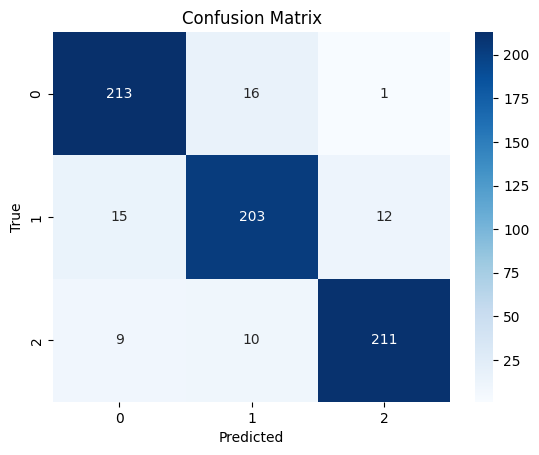

In [9]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Unpack results
filenames, y_true, y_pred = zip(*results)

print(f"✅ Test Accuracy: {accuracy_score(y_true, y_pred):.4f}")
print("\n📊 Classification Report:\n", classification_report(y_true, y_pred))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1,2], yticklabels=[0,1,2])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


In [10]:
df = pd.DataFrame(results, columns=["Filename", "True_Label", "Predicted_Label"])
df.to_csv("test_predictions.csv", index=False)
print("Saved results to test_predictions.csv")


Saved results to test_predictions.csv
